/tmp/ipykernel_16/4204264621.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date, progress=False)
05:56:41 - cmdstanpy - INFO - Chain [1] start processing
05:56:42 - cmdstanpy - INFO - Chain [1] done processing


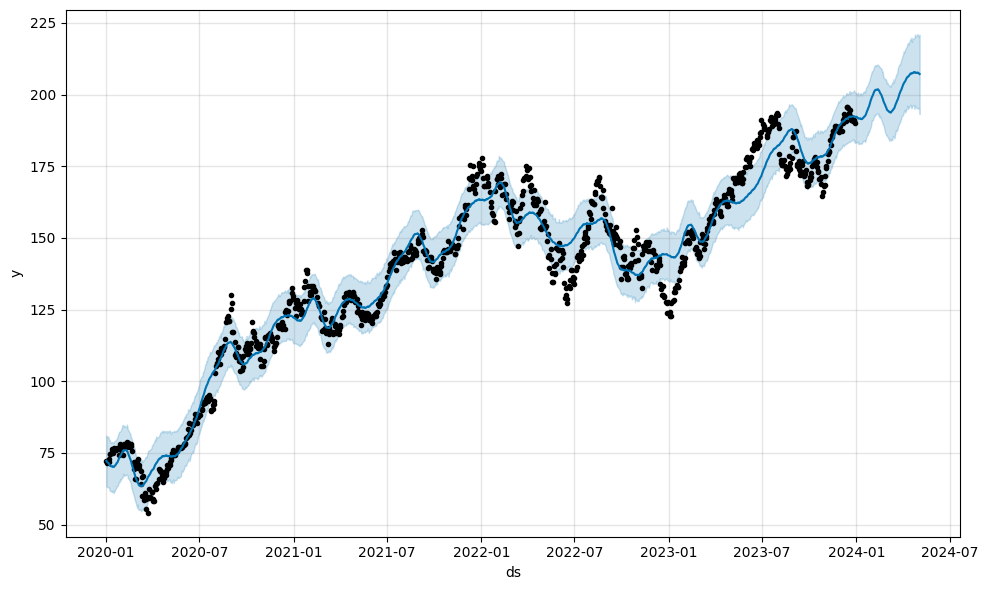

In [1]:
import yfinance as yf
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

ticker = "AAPL"
start_date = "2020-01-01"
end_date = "2024-01-01"
horizon = 90

data = yf.download(ticker, start=start_date, end=end_date, progress=False)
df = data[['Close']].copy()
df.columns = ['Price']

df_prophet = df['Price'].reset_index()
df_prophet.columns = ['ds', 'y']

model = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=True,
    daily_seasonality=False
)
model.fit(df_prophet)

future = model.make_future_dataframe(periods=horizon, freq='B')
forecast = model.predict(future)

fig = model.plot(forecast)
plt.show()

In [2]:
%%writefile app.py
import streamlit as st
import yfinance as yf
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

st.title("Stock Price Forecasting App")

ticker = st.sidebar.selectbox(
    "Select Stock",
    options=["AAPL", "GOOGL", "MSFT", "TSLA", "AMZN", "META", "NFLX", "NVDA"],
    format_func=lambda x: {
        "AAPL": "Apple (AAPL)",
        "GOOGL": "Google (GOOGL)",
        "MSFT": "Microsoft (MSFT)",
        "TSLA": "Tesla (TSLA)",
        "AMZN": "Amazon (AMZN)",
        "META": "Meta (META)",
        "NFLX": "Netflix (NFLX)",
        "NVDA": "NVIDIA (NVDA)"
    }[x]
)

start_date = st.sidebar.date_input("Start Date", value=pd.to_datetime("2020-01-01"))
end_date = st.sidebar.date_input("End Date", value=pd.to_datetime("2024-01-01"))
horizon = st.sidebar.slider("Forecast Horizon (days)", 7, 120, 90)

data = yf.download(ticker, start=start_date, end=end_date, progress=False)
df = data[['Close']].copy()
df.columns = ['Price']

st.line_chart(df['Price'])

df_prophet = df['Price'].reset_index()
df_prophet.columns = ['ds', 'y']

model = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=True,
    daily_seasonality=False
)
model.fit(df_prophet)

future = model.make_future_dataframe(periods=horizon, freq='B')
forecast = model.predict(future)

st.write(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

fig = model.plot(forecast)
st.pyplot(fig)

Writing app.py


In [3]:
%%writefile requirements.txt
streamlit
yfinance
pandas
numpy
matplotlib
prophet

Writing requirements.txt
